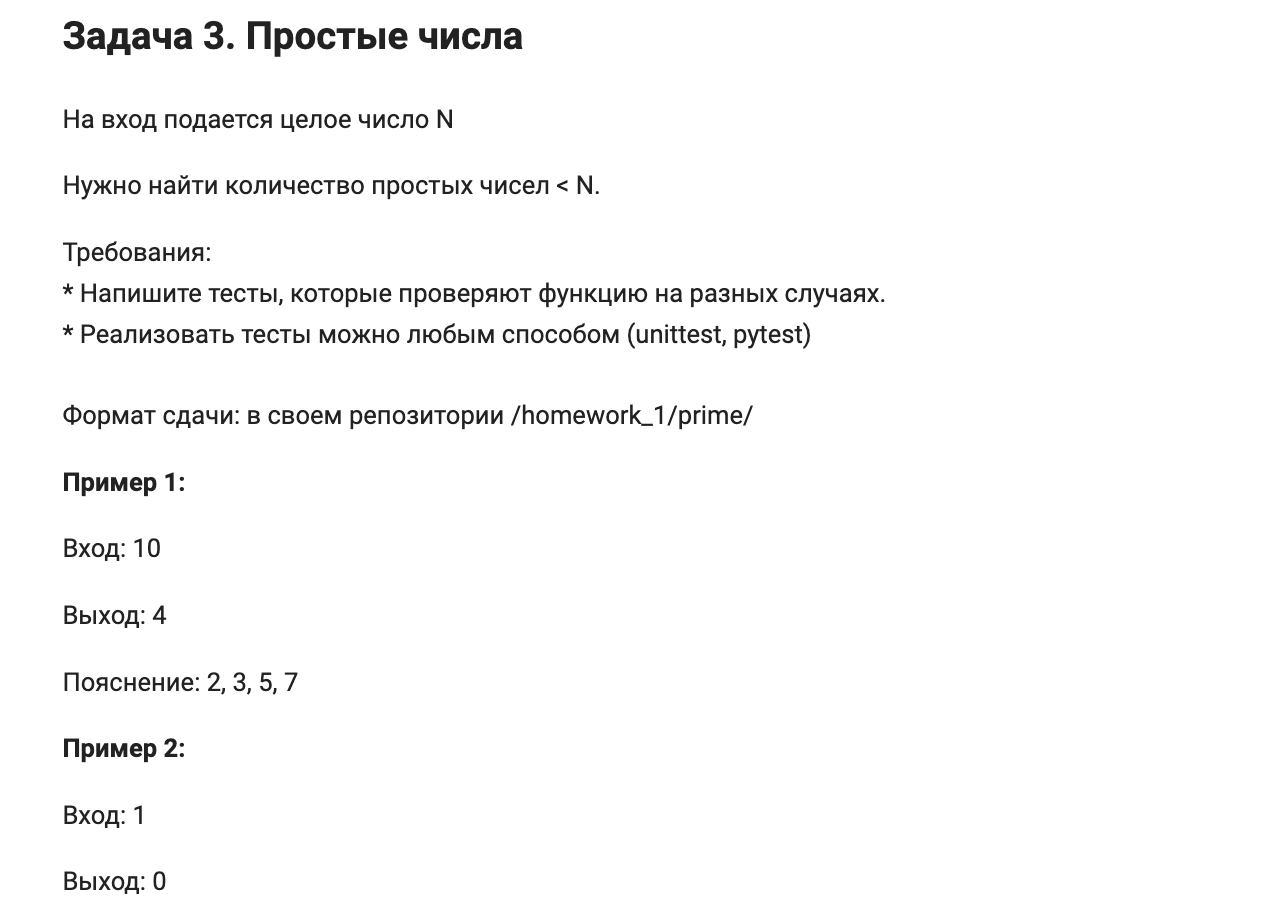

# Ход решения

Будем перебирать все числа `k` от `2` до `N - 1` и для каждого проверять, является ли оно простым. Начинаем с `2`, так 1 это не простое число. Заканчиваем на `N - 1`, так как знак строго меньше в условии задачи.


Очевидно, чтобы проверить число `k`, не нужно искать делители вплоть до `k - 1`. Достаточно проверить числа от `2` до `√k` включительно. Если число `k` составное, то его можно представить как `k = a · b`, и хотя бы один из множителей обязательно будет не больше `√k`. Иначе оба множителя были бы больше `√k`, а их произведение оказалось бы больше `k`.

Поэтому для каждого `k`:
* считаем его простым;
* перебираем возможные делители от `2` до `√k`;
* если нашли делитель без остатка, число составное и дальнейшая проверка не нужна;
* если делитель не найден, увеличиваем счетчик простых чисел.

# Граничные случаи

- Если `N <= 2`, простых чисел `< N` нет, поэтому ответ `0`. Сюда же относятся `0`, `1` и отрицательные `N`. Отрицательные рассматриваем, поскольку из условия они лишь целые.
- `2` — первое простое число, поэтому при `N = 3` ответ равен `1`.
- Само число `N` не проверяем, так как по условию нужны простые числа строго меньше `N`.
- Нецелые значения отдельно не обрабатываем, потому что по условию на вход подается целое число.

# Сложность алгоритма

Пусть `N` — входное число.

- В лучшем случае мы все равно перебираем все числа от 2 до N - 1, и каждое из них оказывается составным, поэтому временная сложность будет Ω(N).
- Для каждого числа `k` в худшем случае проверяем делители до `√k`, то есть не более `√k` делителей. При этом делаем это для каждого числа, то есть итоговая время сложность `O(N * √N) = O(N √N)`.
- Дополнительные структуры данных мы никаких не создаем: храним только несколько переменных, поэтому сложность по памяти — `O(1)`.


# Реализация алгоритма


In [5]:
from math import isqrt

def count_prime_numbers(n):
    count = 0

    for num in range(2, n):
        is_prime = True

        for divisor in range(2, isqrt(num) + 1):
            if num % divisor == 0:
                is_prime = False
                break

        if is_prime:
            count += 1

    return count


# Проверка на нетривиальном примере


In [6]:
n = int(input())
print(count_prime_numbers(n))


15
6


# Визуализация работы алгоритма

Рассмотрим `N = 15`. Нужно проверить числа от `2` до `14`.

| Число `x` | Проверяем делители до `√x` | Результат |
| ---: | --- | --- |
| `2` | делителей нет | простое |
| `3` | делителей нет | простое |
| `4` | `4 % 2 = 0` | составное |
| `5` | `5 % 2 != 0` | простое |
| `6` | `6 % 2 = 0` | составное |
| `7` | `7 % 2 != 0` | простое |
| `8` | `8 % 2 = 0` | составное |
| `9` | `9 % 2 != 0`, `9 % 3 = 0` | составное |
| `10` | `10 % 2 = 0` | составное |
| `11` | `11 % 2 != 0`, `11 % 3 != 0` | простое |
| `12` | `12 % 2 = 0` | составное |
| `13` | `13 % 2 != 0`, `13 % 3 != 0` | простое |
| `14` | `14 % 2 = 0` | составное |

Простые числа `< 15`: `2, 3, 5, 7, 11, 13`.

Итого получаем **`6`** простых чисел.


# Тесты

Проверим:
* оба примера из условия;
* отрицательное `N`, `0`, `1` и `2`;
* минимальное `N`, при котором появляется первое простое число;
* случай, когда `N` само простое и не должно войти в ответ;
* несколько обычных и нетривиальных значений.


In [8]:
import unittest


class TestCountPrimes(unittest.TestCase):
    def test_examples(self):
        self.assertEqual(count_prime_numbers(10), 4)
        self.assertEqual(count_prime_numbers(1), 0)

    def test_non_positive_and_small(self):
        self.assertEqual(count_prime_numbers(-10), 0)
        self.assertEqual(count_prime_numbers(0), 0)
        self.assertEqual(count_prime_numbers(2), 0)
        self.assertEqual(count_prime_numbers(3), 1)

    def test_prime_upper_bound(self):
        self.assertEqual(count_prime_numbers(11), 4)

    def test_typical_values(self):
        self.assertEqual(count_prime_numbers(15), 6)
        self.assertEqual(count_prime_numbers(20), 8)
        self.assertEqual(count_prime_numbers(30), 10)

    def test_larger_value(self):
        self.assertEqual(count_prime_numbers(100), 25)


_ = unittest.main(argv=[''], exit=False)


.....
----------------------------------------------------------------------
Ran 5 tests in 0.015s

OK
